# Automatically generating object masks with SAM
# 利用 SAM 自动生成物体掩膜

## 安装依赖项


In [1]:
%pip install segment-geospatial
%pip install leafmap
%pip install localtileserver
%pip install -U leafmap localtileserver


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.2/157.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.

In [2]:
import leafmap

from samgeo import SamGeo
from samgeo.common import overlay_images, tms_to_geotiff

## 创建交互地图

In [3]:
m = leafmap.Map(center=[37.8713, -122.2580], zoom=17, height="800px")
m.add_basemap("SATELLITE")
m

Map(center=[37.8713, -122.258], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…


平移和缩放地图以选定感兴趣的区域。可以使用绘图工具在地图上绘制多边形或矩形。

In [4]:
if m.user_roi_bounds() is not None:
    bbox = m.user_roi_bounds()
else:
    bbox = [-122.2659, 37.8682, -122.2521, 37.8741]

## 下载影像

In [5]:
image = "satellite.tif"
tms_to_geotiff(output=image, bbox=bbox, zoom=17, source="Satellite", overwrite=True)

Downloaded image 01/24
Downloaded image 02/24
Downloaded image 03/24
Downloaded image 04/24
Downloaded image 05/24
Downloaded image 06/24
Downloaded image 07/24
Downloaded image 08/24
Downloaded image 09/24
Downloaded image 10/24
Downloaded image 11/24
Downloaded image 12/24
Downloaded image 13/24
Downloaded image 14/24
Downloaded image 15/24
Downloaded image 16/24
Downloaded image 17/24
Downloaded image 18/24
Downloaded image 19/24
Downloaded image 20/24
Downloaded image 21/24
Downloaded image 22/24
Downloaded image 23/24
Downloaded image 24/24
Saving GeoTIFF. Please wait...
Image saved to satellite.tif


也可以使用自己的图片。取消注释并运行下面的代码，即可使用自己的图片。

In [ ]:
# image = '/path/to/your/own/image.tif'

在地图上显示下载后的图片。

In [8]:
m.layers[-1].visible = False
m.add_raster(image, layer_name="Image")
m

Map(bottom=3239933.0, center=[37.87115, -122.259], controls=(ZoomControl(options=['position', 'zoom_in_text', …

## 初始化 SAM 类

请指定模型检查点的文件路径。如果未指定，则模型将被下载到工作目录中。

In [9]:
sam = SamGeo(
    model_type="vit_h",
    sam_kwargs=None,
)

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:14<00:00, 183MB/s]


## 自动掩膜生成

将图像分割成多个部分，并将处理结果保存为 GeoTIFF 格式的文件。unique=True为每个对象分配唯一的标识符。

In [10]:
sam.generate(image, output="masks.tif", foreground=True, unique=True)

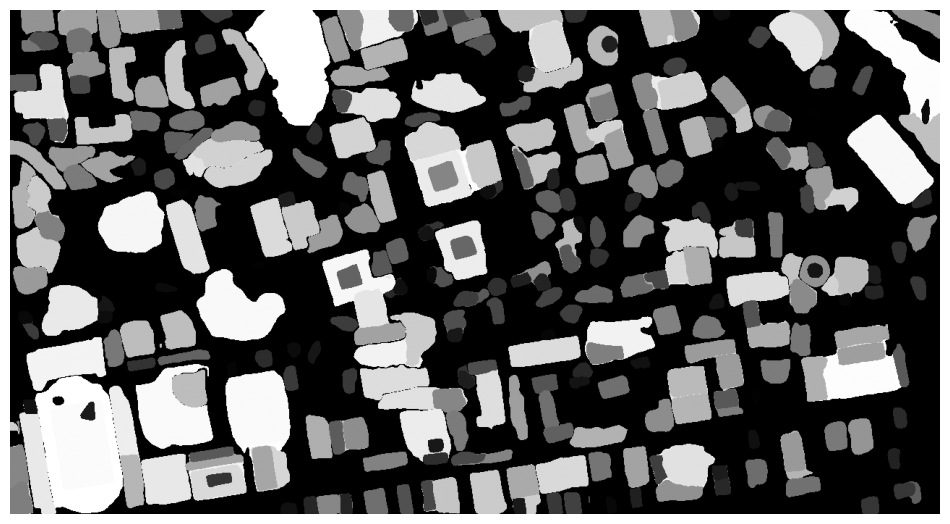

In [11]:
sam.show_masks(cmap="binary_r")

在地图上显示这些对象的标注信息（被随机着色的对象）。

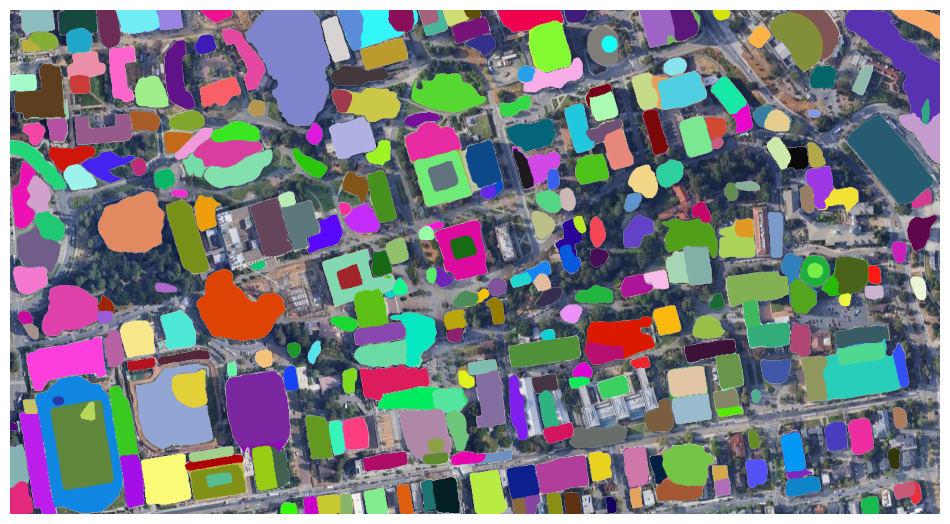

In [12]:
sam.show_anns(axis="off", alpha=1, output="annotations.tif")

使用滑块来比较图片


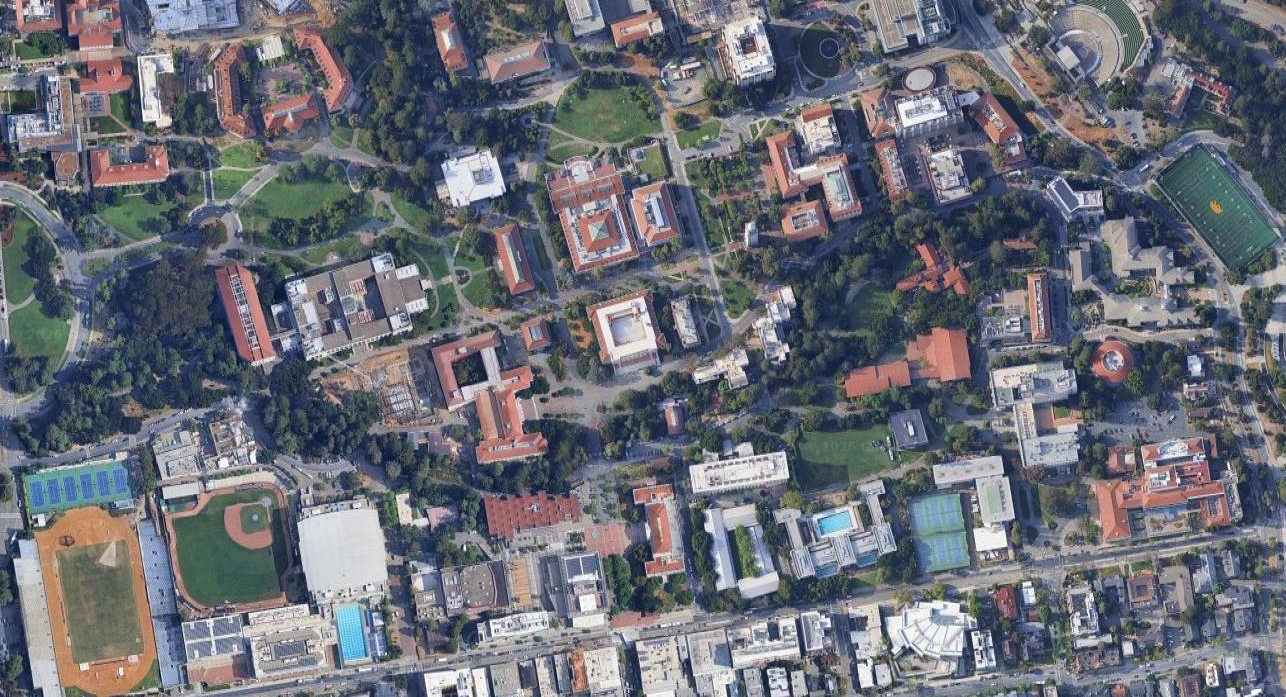
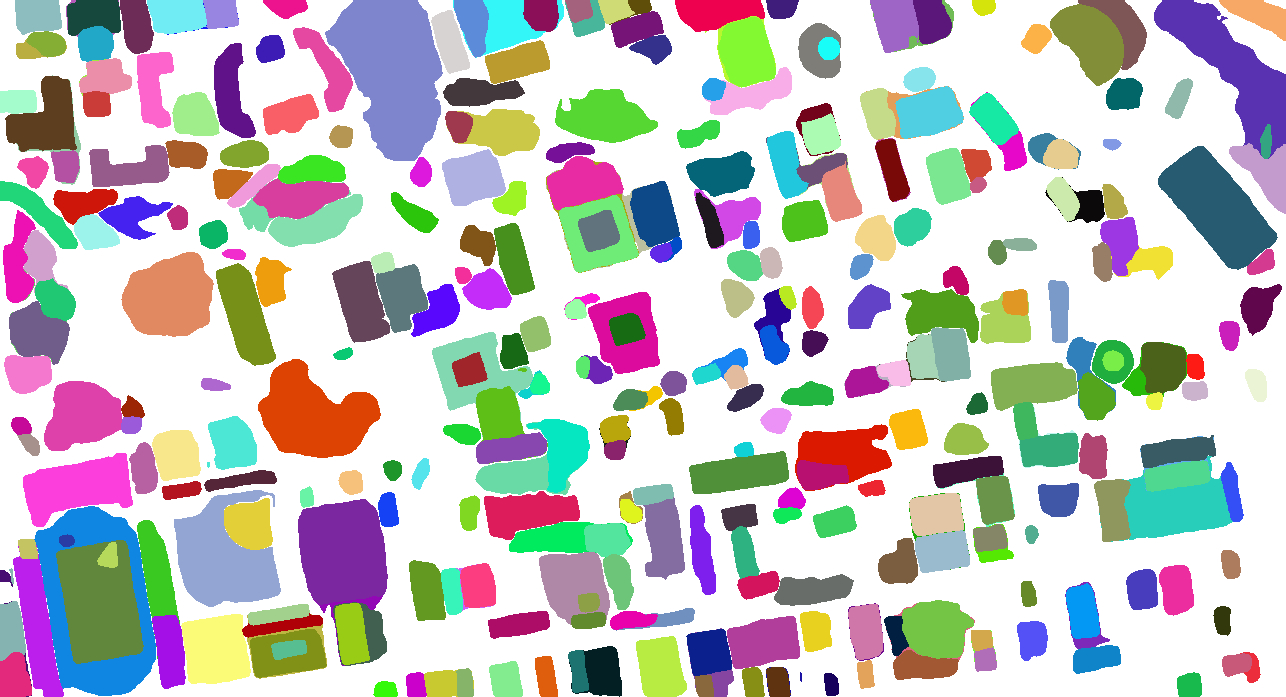

In [13]:
leafmap.image_comparison(
    "satellite.tif",
    "annotations.tif",
    label1="Satellite Image",
    label2="Image Segmentation",
)

把图片添加到地图中

In [14]:
m.add_raster("annotations.tif", alpha=0.5, layer_name="Masks")
m

Map(bottom=3239933.0, center=[37.87115, -122.259], controls=(ZoomControl(options=['position', 'zoom_in_text', …

将对象标注转换为向量格式，例如 GeoPackage、Shapefile 或 GeoJSON。

In [15]:
sam.tiff_to_vector("masks.tif", "masks.gpkg")

## 自动掩膜生成选项

有若干可调节的参数。这些参数决定了点的采样密度，以及用于过滤低质量或重复遮罩的阈值。此外，该过程还可以针对图像的特定区域进行自动处理，从而提升对较小物体的处理效果。后期处理则可以去除那些多余的像素和空洞。以下是一个会生成更多遮罩的示例配置：

In [16]:
sam_kwargs = {
    "points_per_side": 32,
    "pred_iou_thresh": 0.86,
    "stability_score_thresh": 0.92,
    "crop_n_layers": 1,
    "crop_n_points_downscale_factor": 2,
    "min_mask_region_area": 100,
}

In [17]:
sam = SamGeo(
    model_type="vit_h",
    sam_kwargs=sam_kwargs,
)

In [18]:
sam.generate(image, output="masks2.tif", foreground=True)

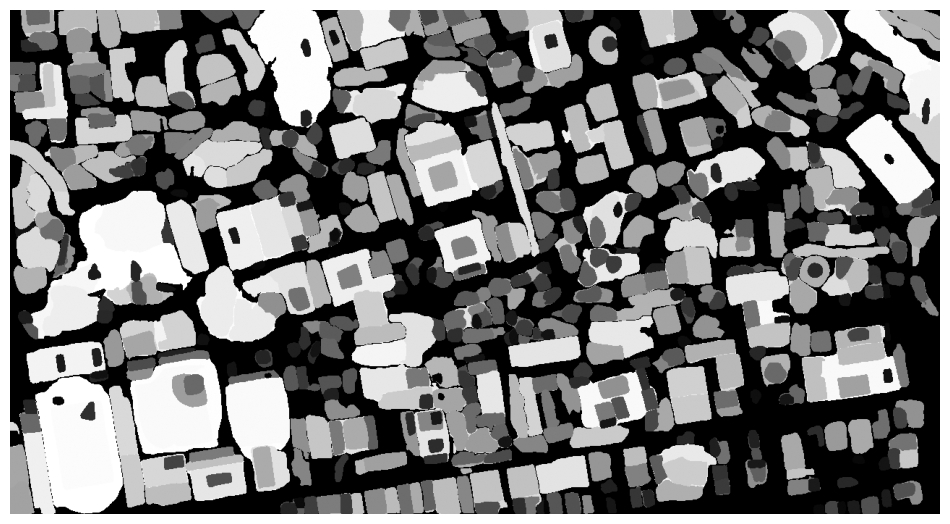

In [19]:
sam.show_masks(cmap="binary_r")

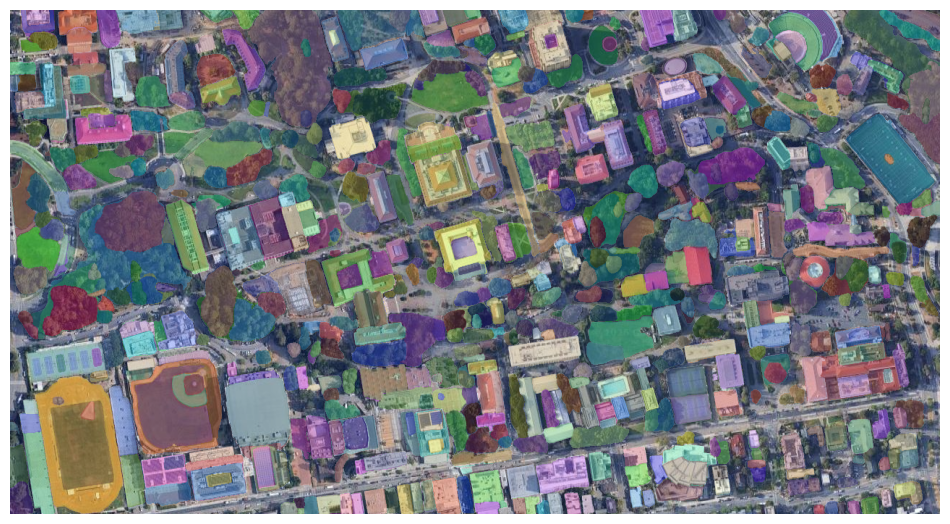

In [20]:
sam.show_anns(axis="off", opacity=1, output="annotations2.tif")

使用滑块来比较图片。


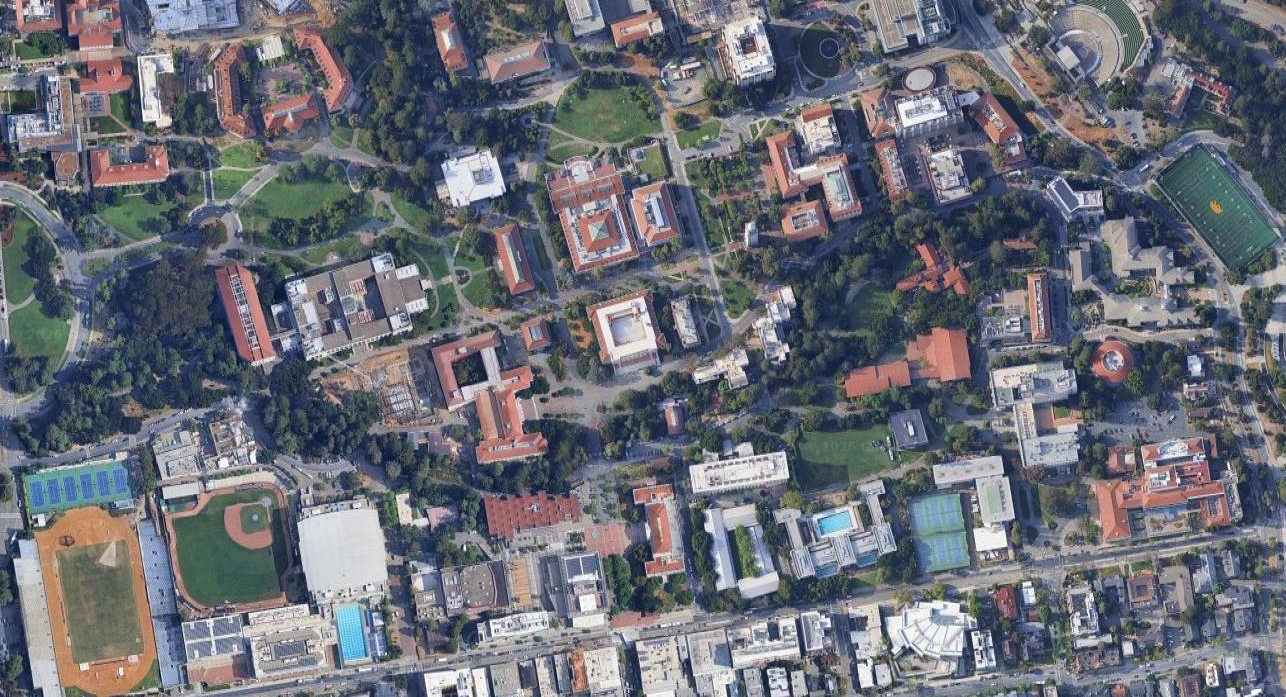
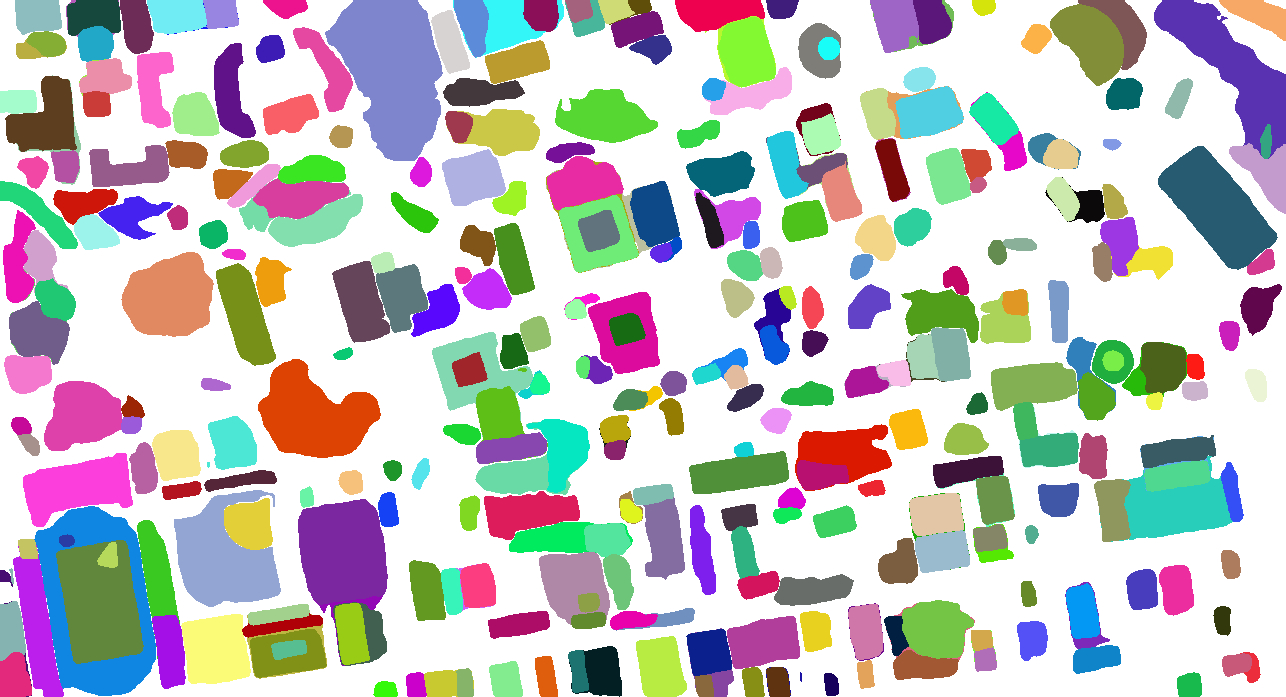

In [21]:
leafmap.image_comparison(
    image,
    "annotations.tif",
    label1="Image",
    label2="Image Segmentation",
)

将标记叠加在图像上，然后使用滑块来动态调整标记的透明度。

In [22]:
overlay_images(image, "annotations2.tif", backend="TkAgg")

The TkAgg backend is not supported in Google Colab. The overlay_images function will not work on Colab.


![](https://i.imgur.com/I1IhDgz.gif)